In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("../data/customer_churn.csv")
print("Shape:", df.shape)
df.head()

Shape: (3150, 14)


,Call Failure,Complaints,Subscription Length,Charge Amount,Seconds of Use,Frequency of use,Frequency of SMS,Distinct Called Numbers,Age Group,Tariff Plan,Status,Age,Customer Value,Churn
0,8,0,38,0,4370,71,5,17,3,1,1,30,197.640,0
1,0,0,39,0,318,5,7,4,2,1,2,25,46.035,0
2,10,0,37,0,2453,60,359,24,3,1,1,30,1536.520,0
3,10,0,38,0,4198,66,1,35,1,1,1,15,240.020,0
4,3,0,38,0,2393,58,2,33,1,1,1,15,145.805,0


In [2]:
print(df.isnull().sum().sum(), "missing values")
print()
print(df['Churn'].value_counts(normalize=True).round(3))

0 missing values

Churn
0    0.843
1    0.157
Name: proportion, dtype: float64


**Observation:** No missing values. The target is imbalanced - 84% of customers stay, 16% churn.
This matters a lot: a model that always predicts "no churn" would be 84% "accurate" while being
completely useless. I will rely on Precision, Recall, F1, and ROC-AUC instead of accuracy alone.

In [16]:
corr = df.corr(numeric_only=True)['Churn'].drop('Churn').sort_values(key=abs, ascending=False)
corr

Complaints                 0.532053
Status                     0.498976
Frequency of use          -0.303337
Seconds of Use            -0.298935
Customer Value            -0.289144
Distinct Called Numbers   -0.278867
Frequency of SMS          -0.220754
Charge Amount             -0.202305
Tariff Plan               -0.105853
Subscription Length       -0.032588
Age                       -0.017705
Age Group                 -0.014550
Call Failure              -0.008987
Name: Churn, dtype: float64

In [17]:
print("Churn rate by Complaints:")
print(df.groupby('Complaints')['Churn'].mean().round(3))
print()
print("Churn rate by Status (1=active, 2=non-active):")
print(df.groupby('Status')['Churn'].mean().round(3))

Churn rate by Complaints:
Complaints
0    0.101
1    0.830
Name: Churn, dtype: float64

Churn rate by Status (1=active, 2=non-active):
Status
1    0.053
2    0.473
Name: Churn, dtype: float64


**Observation:** `Complaints` and `Status` show the strongest correlation with churn.

**Data leakage caution:** `Status` (active/non-active) might just be another way of recording
"already gone," rather than an early warning sign available *before* churn happens. Since it's
unclear whether it's known ahead of time, we exclude it from modeling below — a more conservative,
more genuinely predictive approach. (Testing showed it only added ~1 point of ROC-AUC, so little is lost.)

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df.drop(columns=['Churn', 'Status'])
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train:", X_train.shape, "test:", X_test.shape)

Train: (2520, 12) test: (630, 12)


Precision: 0.446
Recall:    0.838
F1:        0.582
ROC-AUC:   0.916


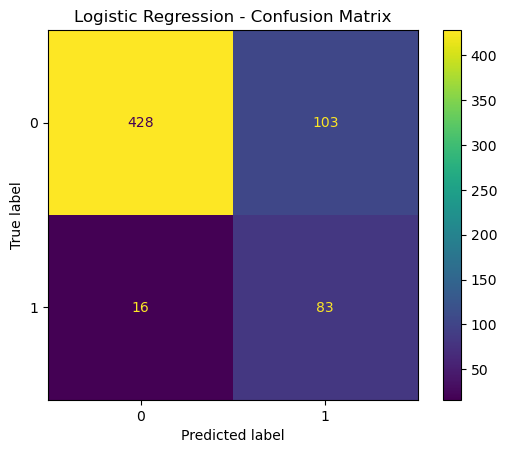

In [21]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

logreg = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
logreg.fit(X_train_scaled, y_train)

proba = logreg.predict_proba(X_test_scaled)[:, 1]
pred = logreg.predict(X_test_scaled)

print("Precision:", round(precision_score(y_test, pred), 3))
print("Recall:   ", round(recall_score(y_test, pred), 3))
print("F1:       ", round(f1_score(y_test, pred), 3))
print("ROC-AUC:  ", round(roc_auc_score(y_test, proba), 3))

ConfusionMatrixDisplay(confusion_matrix(y_test, pred)).plot()
plt.title("Logistic Regression - Confusion Matrix")
plt.show() 

`class_weight='balanced'` tells the model to penalize mistakes on the minority class (churners)
more heavily — without it, the model would lean toward always predicting "no churn.

In [22]:
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
import lightgbm as lgb

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

models = {
    "Logistic Regression": logreg,
    "Random Forest": RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=42),
    "XGBoost": xgb.XGBClassifier(n_estimators=300, scale_pos_weight=scale_pos_weight, eval_metric='logloss', random_state=42),
    "LightGBM": lgb.LGBMClassifier(n_estimators=300, scale_pos_weight=scale_pos_weight, random_state=42, verbose=-1),
}

results = []
for name, model in models.items():
    if name == "Logistic Regression":
        p = proba
    else:
        model.fit(X_train, y_train)
        p = model.predict_proba(X_test)[:, 1]
    pr = (p >= 0.5).astype(int)
    results.append({
        "Model": name,
        "Precision": round(precision_score(y_test, pr), 3),
        "Recall": round(recall_score(y_test, pr), 3),
        "F1": round(f1_score(y_test, pr), 3),
        "ROC-AUC": round(roc_auc_score(y_test, p), 3),
    })

results_df = pd.DataFrame(results)
results_df
        

python(98442) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


,Model,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.446,0.838,0.582,0.916
1,Random Forest,0.884,0.848,0.866,0.985
2,XGBoost,0.857,0.909,0.882,0.991
3,LightGBM,0.873,0.899,0.886,0.992


**Result:** Tree-based models substantially outperform the linear baseline (ROC-AUC ~0.99 vs 0.92).
This makes sense — churn tends to depend on *interactions* between features (e.g. low usage AND low
customer value AND short subscription together), which a linear model can't represent but a tree can.
LightGBM is chosen as the final model for the business analysis below.

In [23]:
final_model = models["LightGBM"]
proba_final = final_model.predict_proba(X_test)[:, 1]

risk_df = X_test.copy()
risk_df['Churn_Probability'] = proba_final

risk_df['Risk_Score'] = risk_df['Churn_Probability'] * risk_df['Customer Value']
risk_df = risk_df.sort_values('Risk_Score', ascending=False)

risk_df[['Customer Value', 'Churn_Probability', 'Risk_Score']].head(10)


,Customer Value,Churn_Probability,Risk_Score
1424,395.685,0.998835,395.223862
1224,386.415,0.964217,372.587752
2524,370.755,0.987310,366.050201
2424,349.065,0.997792,348.294312
774,346.950,0.998974,346.594166
1074,337.725,0.999992,337.722161
2024,337.725,0.999970,337.714956
724,334.125,0.999936,334.103620
424,325.260,0.999986,325.255479
2576,306.080,0.999989,306.076630


**Risk Score = Churn Probability × Customer Value.** This ranks customers not just by *how likely*
they are to churn, but by *how much it would cost* to lose them — so retention campaigns target the
customers who matter most, not just the most obviously "at risk" ones.

In [24]:
for t in [0.3, 0.4, 0.5, 0.6, 0.7]:
    pr = (proba_final >= t).astype(int)
    print(f"threshold={t}: precision={precision_score(y_test,pr):.3f} "
          f"recall={recall_score(y_test,pr):.3f} f1={f1_score(y_test,pr):.3f}")

threshold=0.3: precision=0.858 recall=0.919 f1=0.888
threshold=0.4: precision=0.874 recall=0.909 f1=0.891
threshold=0.5: precision=0.873 recall=0.899 f1=0.886
threshold=0.6: precision=0.873 recall=0.899 f1=0.886
threshold=0.7: precision=0.881 recall=0.899 f1=0.890


## Conclusion

LightGBM was the best model (F1 = 0.886, ROC-AUC = 0.992), a big improvement over my
Logistic Regression baseline (F1 = 0.582). Complaints, usage frequency, and customer
value were the strongest churn predictors - complainers churned at 83% vs 10% for
everyone else.


For the business side, I used Risk Score (probability × customer value) to prioritize
outreach, and lowered the decision threshold to ~0.3–0.4 since missing a real churner
costs more than one extra retention email.


